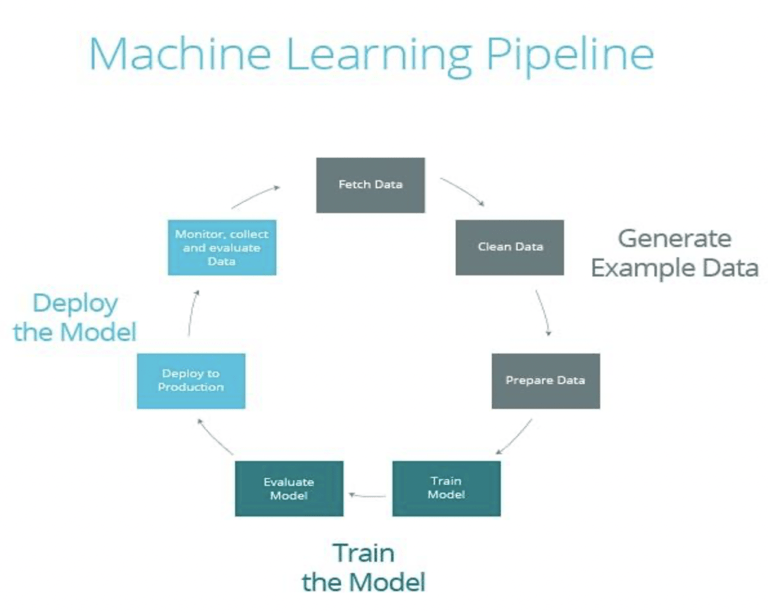

## ➿ Machine learning loop

### 🎒 Packages

In [38]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
pd.set_option('display.max_colwidth', None)
import random

---

### 🚙 Utilities

In [3]:
train_path = Path("..") / "data" / "train.csv"
# only used for final outputing (estimation on real data)
test_path = Path("..") / "data" / "test.csv"
# store
store_path = Path("..") / "data" / "store.csv"

In [4]:
pastel_colors = sns.color_palette("pastel")

def color():
    color = random.choice(pastel_colors)
    return color

---

### 📊 Data + Simple preprocessing to fill NA

#### 🫦 Problem of mixed types ✅

In [5]:
train = pd.read_csv(
    train_path,
    parse_dates=["Date"],
    dtype={"StateHoliday": "str"}
)

In [6]:
train = pd.read_csv(filepath_or_buffer=train_path, parse_dates=["Date"], low_memory=False)
test = pd.read_csv(filepath_or_buffer=test_path, parse_dates=["Date"])
store = pd.read_csv(filepath_or_buffer=store_path)

In [7]:
store.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [72]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1115 non-null   float64
 4   CompetitionOpenSinceMonth  1115 non-null   float64
 5   CompetitionOpenSinceYear   1115 non-null   float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


#### 🎖️ Fill the NA with median on the competition distance

In [23]:
store["CompetitionDistance"] = store["CompetitionDistance"].fillna(store["CompetitionDistance"].median())

##### 🎖️ Fill the NAN of the Competition's open's month and year

In [73]:
# Assume that the competition opens for a very long day
# fill in that the competition has opened for a long term ago

year = store["CompetitionOpenSinceYear"].min()
store["CompetitionOpenSinceYear"] = store["CompetitionOpenSinceYear"].fillna(year)

store["CompetitionOpenSinceMonth"] = store["CompetitionOpenSinceMonth"].fillna(1)

#### 🎖️ Fill the NaN for the Promo2 (long-term promotion), when the promo2 == 0 -> Then features like year contain no meaning

In [81]:
# Fill sentinal
def sentimal_promo2(row):
    if row["Promo2"]:
        return row
    
    else:
        row["Promo2SinceWeek"] = -1
        row["Promo2SinceYear"] = -1
        row["PromoInterval"] = ""
        return row
        

store = store.apply(sentimal_promo2, axis=1)

In [83]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1115 non-null   float64
 4   CompetitionOpenSinceMonth  1115 non-null   float64
 5   CompetitionOpenSinceYear   1115 non-null   float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            1115 non-null   float64
 8   Promo2SinceYear            1115 non-null   float64
 9   PromoInterval              1115 non-null   str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [74]:
train.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [47]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  str           
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[us](1), int64(7), str(1)
memory usage: 69.8 MB


In [9]:
train["StateHoliday"].describe()

count     1017209
unique          4
top             0
freq       986159
Name: StateHoliday, dtype: object

In [10]:
test.head(5)

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


---

### 🥼 Feature engineerings

##### 🈂️ Merge train and store, each record = sale on that day and the store's information

In [84]:
df = train.merge(store, on="Store", how="left")

In [85]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,-1.0,-1.0,
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,-1.0,-1.0,
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,-1.0,-1.0,


##### 🦢 Date features

In [86]:
# convert Date into Dates (for processing)
df["Date"] = pd.to_datetime(df["Date"])

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["weekofyear"] = df["Date"].dt.isocalendar().week
df["is_weekend"] = df["DayOfWeek"].isin([6,7]).astype(int)

In [87]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,2008.0,0,-1.0,-1.0,,2015,7,31,31,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,2009.0,0,-1.0,-1.0,,2015,7,31,31,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,2015.0,0,-1.0,-1.0,,2015,7,31,31,0


#### 🔩 Competition duration

In [88]:
# calculate the number of months that the competition store has opened
df["CompetitionOpenSince"] = (
    (df["year"] - df["CompetitionOpenSinceYear"]) * 12 +
    (df["month"] - df["CompetitionOpenSinceMonth"])
)
df["CompetitionOpenSince"] = df["CompetitionOpenSince"].clip(lower=0)

In [89]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,0,-1.0,-1.0,,2015,7,31,31,0,82.0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,92.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,103.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,0,-1.0,-1.0,,2015,7,31,31,0,70.0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,0,-1.0,-1.0,,2015,7,31,31,0,3.0


#### 🧾 Promo2 (long-term impact)

In [90]:
# Calculate the number of weeks that the promo2 has been applied
df["Promo2Since"] = (
    (df["year"] - df["Promo2SinceYear"]) * 52 +
    (df["weekofyear"] - df["Promo2SinceWeek"])
)
df["Promo2Since"] = df["Promo2Since"].clip(lower=0)

In [91]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,-1.0,-1.0,,2015,7,31,31,0,82.0,104864.0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,92.0,278.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,103.0,225.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,-1.0,-1.0,,2015,7,31,31,0,70.0,104864.0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,-1.0,-1.0,,2015,7,31,31,0,3.0,104864.0


In [92]:
month_str = df["Date"].dt.strftime("%b")

# The current day is in the Promo2 or not
df["IsPromoMonth"] = df.apply(
    lambda x: 1 if isinstance(x["PromoInterval"], str) and month_str[x.name] in x["PromoInterval"] else 0,
    axis=1
)

In [93]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since,IsPromoMonth
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,-1.0,,2015,7,31,31,0,82.0,104864.0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,92.0,278.0,1
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,103.0,225.0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,-1.0,,2015,7,31,31,0,70.0,104864.0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,-1.0,,2015,7,31,31,0,3.0,104864.0,0


#### 🗼 One hot encoding for categorical columns

In [94]:
# Convert labels into simple labels
for col in ["StoreType", "Assortment", "StateHoliday"]:
    df[col] = df[col].astype("category").cat.codes

In [95]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since,IsPromoMonth
0,1,5,2015-07-31,5263,555,1,1,0,1,2,...,-1.0,,2015,7,31,31,0,82.0,104864.0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,0,...,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,92.0,278.0,1
2,3,5,2015-07-31,8314,821,1,1,0,1,0,...,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,103.0,225.0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,2,...,-1.0,,2015,7,31,31,0,70.0,104864.0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,0,...,-1.0,,2015,7,31,31,0,3.0,104864.0,0


In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 26 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  int8          
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  int8          
 10  Assortment                 1017209 non-null  int8          
 11  CompetitionDistance        1017209 non-null  flo

#### 💫 Closed -> Sales = 0, we want the model to learn the Sales when store is open (pure), we don't want it to learn deterministic rules

In [98]:
df = df[df["Open"] == 1]

#### 🍰 No lag features now, meaning we just use the current information of the store to predict the current Sales

❌ Store's information contains NaN and Null values

In [99]:
df["Date"].min()

Timestamp('2013-01-01 00:00:00')

In [100]:
df["Date"].max()

Timestamp('2015-07-31 00:00:00')

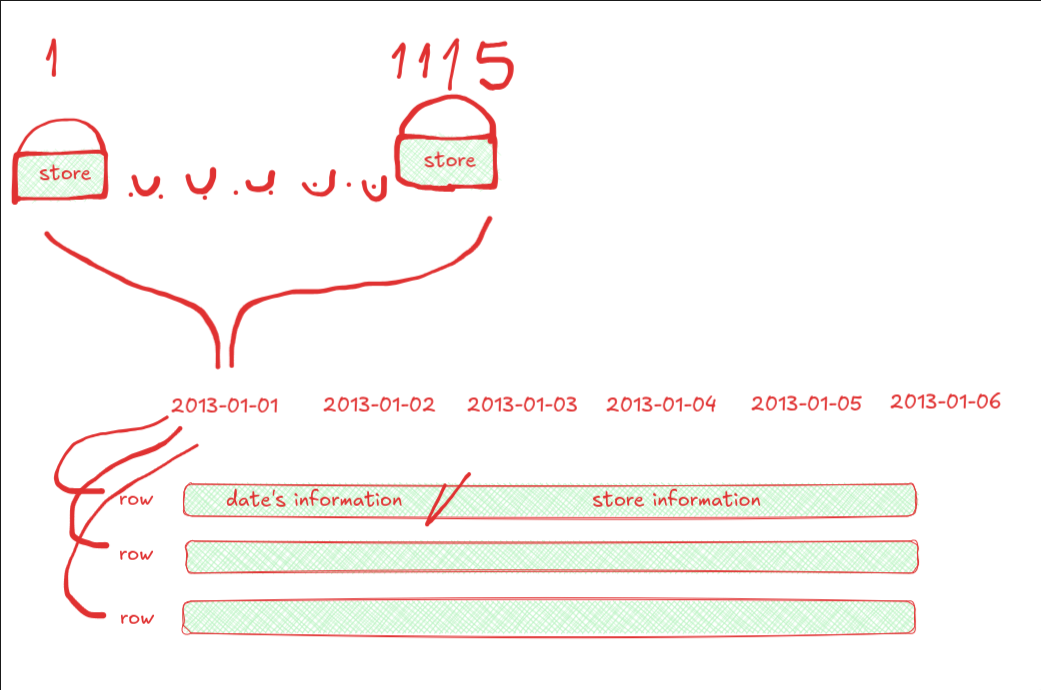

In [101]:
df.info()

<class 'pandas.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[us]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  int8          
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  int8          
 10  Assortment                 844392 non-null  int8          
 11  CompetitionDistance        844392 non-null  float64       
 12  Com

In [102]:
df = df.sort_values(by=["Date", "Store"]).reset_index(drop=True)

In [103]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since,IsPromoMonth
0,85,2,2013-01-01,4220,619,1,0,1,1,1,...,-1.0,,2013,1,1,1,0,15.0,104730.0,0
1,259,2,2013-01-01,6851,1444,1,0,1,1,1,...,-1.0,,2013,1,1,1,0,1356.0,104730.0,0
2,262,2,2013-01-01,17267,2875,1,0,1,1,1,...,-1.0,,2013,1,1,1,0,0.0,104730.0,0
3,274,2,2013-01-01,3102,729,1,0,1,1,1,...,2013.0,"Jan,Apr,Jul,Oct",2013,1,1,1,0,1356.0,0.0,1
4,335,2,2013-01-01,2401,482,1,0,1,1,1,...,2013.0,"Jan,Apr,Jul,Oct",2013,1,1,1,0,1356.0,0.0,1


#### 📧 Final features

In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[us]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  int8          
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  int8          
 10  Assortment                 844392 non-null  int8          
 11  CompetitionDistance        844392 non-null  float64       
 12 

In [107]:
features = [
 "Store",                      # 844392 non-null  int64         
 "DayOfWeek",                  # 844392 non-null  int64         
 # 2   Date                       # 844392 non-null  datetime64[us]
 # 3   Sales                      # 844392 non-null  int64         
 # 4   Customers                  # 844392 non-null  int64         
 # 5   Open                       # 844392 non-null  int64         
 "Promo",                      # 844392 non-null  int64         
 "StateHoliday",               # 844392 non-null  int8          
 "SchoolHoliday",              # 844392 non-null  int64         
 "StoreType",                  # 844392 non-null  int8          
 "Assortment",                 # 844392 non-null  int8          
 "CompetitionDistance",        # 844392 non-null  float64       
 # 12  CompetitionOpenSinceMonth  # 575773 non-null  float64       
 # 13  CompetitionOpenSinceYear   # 575773 non-null  float64       
 "Promo2",                     # 844392 non-null  int64         
 # 15  Promo2SinceWeek            # 421085 non-null  float64       
 # 16  Promo2SinceYear            # 421085 non-null  float64       
 # 17  PromoInterval              # 421085 non-null  str           
 "year",                       # 844392 non-null  int32         
 "month",                      # 844392 non-null  int32         
 "day",                        # 844392 non-null  int32         
 "weekofyear",                 # 844392 non-null  UInt32        
 "is_weekend",                 # 844392 non-null  int64         
 "CompetitionOpenSince",       # 575773 non-null  float64       
 "Promo2Since",                # 421085 non-null  Float64       
 "IsPromoMonth",               # 844392 non-null  int64   
]

target = [
    "Sales"
]

In [108]:
X = df[features]
y = df[target]

### 🌵 Data spliting

#### 💦 Applying expand window

In [ ]:
val_days = 42
n_folds = 4

In [112]:
def create_expanding_folds_with_cutoffs(
    df,
    date_col="Date",
    cutoffs=None,
    val_days=42
):
    df = df.sort_values(date_col).reset_index(drop=True)

    cutoffs = [pd.to_datetime(c) for c in cutoffs]

    folds = []

    for i, cutoff in enumerate(cutoffs):
        # start = cutoff
        val_start = cutoff
        # end = cutoff + 42
        val_end = cutoff + pd.Timedelta(days=val_days)

        train = df[df[date_col] < val_start]
        val = df[(df[date_col] >= val_start) & (df[date_col] < val_end)]

        folds.append({
            "fold": i + 1,
            "cutoff": cutoff,
            "train": train,
            "val": val,
        })

    return folds

In [113]:
pd.Timestamp("2015-07-31") - pd.Timedelta(days=42)

Timestamp('2015-06-19 00:00:00')

In [127]:
cutoffs = [
    "2014-06-01",
    "2014-09-01",
    "2014-12-01",
    "2015-06-20"
]

folds = create_expanding_folds_with_cutoffs(df, cutoffs=cutoffs)

In [128]:
fold_3 = folds[3]

In [129]:
train, val = fold_3["train"], fold_3["val"]

In [130]:
val.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceWeek,Promo2SinceYear,year,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since,IsPromoMonth
count,40282.000000,40282.000000,40282,40282.000000,40282.000000,40282.0,40282.000000,40282.0,40282.000000,40282.000000,...,40282.000000,40282.00000,40282.0,40282.000000,40282.000000,40282.0,40282.000000,40282.000000,40282.0,40282.000000
mean,558.042699,3.516707,2015-07-10 19:34:25.696837,6978.638052,732.996500,1.0,0.414602,0.0,0.330272,1.216623,...,11.554292,1027.41850,2015.0,6.749417,18.333077,28.32841,0.170672,491.718063,51371.012139,0.248920
min,1.000000,1.000000,2015-06-20 00:00:00,569.000000,75.000000,1.0,0.000000,0.0,0.000000,0.000000,...,-1.000000,-1.00000,2015.0,6.000000,1.000000,25.0,0.000000,0.000000,2.0,0.000000
25%,279.000000,2.000000,2015-06-30 00:00:00,4919.250000,506.000000,1.0,0.000000,0.0,0.000000,0.000000,...,-1.000000,-1.00000,2015.0,6.000000,11.000000,27.0,0.000000,44.000000,165.0,0.000000
50%,558.000000,4.000000,2015-07-10 00:00:00,6384.000000,649.000000,1.0,0.000000,0.0,0.000000,0.000000,...,1.000000,2009.00000,2015.0,7.000000,21.000000,28.0,0.000000,105.000000,305.0,0.000000
75%,836.000000,5.000000,2015-07-21 00:00:00,8367.000000,848.000000,1.0,1.000000,0.0,1.000000,3.000000,...,22.000000,2012.00000,2015.0,7.000000,26.000000,30.0,0.000000,1385.000000,104861.0,0.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,4783.000000,1.0,1.000000,0.0,1.000000,3.000000,...,50.000000,2015.00000,2015.0,7.000000,31.000000,31.0,1.000000,1386.000000,104864.0,1.000000
std,321.758056,1.720851,NaN,3054.712900,386.673294,0.0,0.492659,0.0,0.470317,1.367391,...,15.902411,1006.15503,0.0,0.433354,8.925962,1.748821,0.376227,613.149941,52332.340817,0.432393


### 🧹 Modeling

### 🎃 Evaluation